In [1]:
import pandas as pd
import numpy as np

import torch
from torch import nn
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

In [2]:
import random

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

In [3]:
import geopandas as gpd
from libpysal.weights import Queen

gdf = gpd.read_file("../Output/Geo Output/London_LSOA_2021.shp").sort_values("LSOA21CD").reset_index(drop=True)

w = Queen.from_dataframe(gdf)
edges, weights = [], []

for src, neighbors in w.neighbors.items():
    for tgt in neighbors:
        geom_src = gdf.geometry.iloc[src]
        geom_tgt = gdf.geometry.iloc[tgt]
        inter = geom_src.intersection(geom_tgt)
        weight = inter.length if inter.length > 0 else 0.001
        edges.append([src, tgt])
        weights.append(weight)
        edges.append([tgt, src])
        weights.append(weight)
        
edge_index = torch.tensor(edges, dtype=torch.long).T
edge_weight = torch.tensor(weights, dtype=torch.float32)

C:\Users\wbwha\AppData\Local\Temp\ipykernel_31844\3828378298.py:6: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


In [12]:
from sklearn.model_selection import StratifiedKFold

# ===============================
# Choose dataset for model type
# ===============================
# For GCN (static features):
X_train_sbert = torch.load("../Output/Pred Input/embedding_only_xgboost_gcn.pt")
X_train_sbert =X_train_sbert["X"]
X_train = X_train_sbert        # shape [N, F]

# For GCN-LSTM (temporal features):
X_train_topic200 = torch.load("../Output/Pred Input/topic_top200_train_gcnlstm.pt")
X_train_topic200 = X_train_topic200["X"]
X_train_ = X_train_topic200   # shape [N, T, F]

# Labels
y_train = torch.load("../Output/Pred Input/y_train_5.pt")
y_train = y_train.to(torch.long)   # ensure integer class labels

# Move to device
device = X_train.device if X_train.is_cuda else ("cuda" if torch.cuda.is_available() else "cpu")
X_train = X_train.to(device)
y_train = y_train.to(device)

# ===============================
# Seeds and folds
# ===============================
# Random seeds for multiple runs
seeds = [0, 1, 2]

# Stratified 5-fold split
y_np = y_train.cpu().numpy()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_indices = list(skf.split(np.arange(len(y_np)), y_np))

print(f"Prepared {len(fold_indices)} folds, each with train/val indices")
print(f"Using seeds: {seeds}")
print(f"X_train shape = {tuple(X_train.shape)}, y_train shape = {tuple(y_train.shape)}")

Prepared 5 folds, each with train/val indices
Using seeds: [0, 1, 2]
X_train shape = (4994, 384), y_train shape = (4994,)


In [21]:
# Re-run best config (GCN / GCN-LSTM)
# Visualizes mean±std loss curves, macro/weighted F1, and per-class F1 curves

import os, random

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, f1_score, recall_score
from sklearn.utils.class_weight import compute_class_weight

from Loss_Functions.Focal_Loss import FocalLossMultiClass
from Hybrid_Models.Gen_GCN_MLP import GentrificationGCN
from Hybrid_Models.Gen_GCN_LSTM_MLP import GentrificationGCN_LSTM


# ---------- shared helpers ----------
def _compute_class_weights(y_np_train, n_classes, device):
    """Compute balanced class weights on the current train split."""
    classes_present = np.unique(y_np_train)
    weights_partial = compute_class_weight(class_weight='balanced',
                                           classes=classes_present,
                                           y=y_np_train)
    full = np.zeros(n_classes, dtype=np.float32)
    for i, cls in enumerate(classes_present):
        full[int(cls)] = weights_partial[i]
    if (full == 0).any():
        nz = full[full > 0]
        full[full == 0] = nz.min() if len(nz) > 0 else 1.0
    return torch.tensor(full, dtype=torch.float32, device=device)


def _loss_variants():
    """Return dict of loss builders (given class weights tensor)."""
    return {
        "CE":           lambda w: torch.nn.CrossEntropyLoss(weight=w),
        "Focal_gamma1": lambda w: FocalLossMultiClass(alpha=w, gamma=1.0),
        "Focal_gamma2": lambda w: FocalLossMultiClass(alpha=w, gamma=2.0),
    }


def _eval_on_mask(logits, y_true_tensor, mask, n_classes):
    """Compute metrics on a boolean mask (including per-class F1)."""
    y_true = y_true_tensor[mask].cpu().numpy()
    y_pred = logits[mask].argmax(dim=1).cpu().numpy()
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    rec_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_per_class = f1_score(y_true, y_pred, average=None,
                            labels=np.arange(n_classes), zero_division=0)
    return acc, f1_macro, f1_weighted, rec_macro, f1_per_class


def _aggregate_histories(histories_df, out_dir, title_prefix):
    """Aggregate histories across folds×seeds, then plot loss/F1 and per-class F1."""
    # Aggregate (mean,std) for all numeric columns except 'epoch'
    agg = histories_df.groupby("epoch").agg(
        {col: ["mean", "std"] for col in histories_df.columns if col != "epoch"}
    ).reset_index()

    os.makedirs(out_dir, exist_ok=True)

    # === Loss curves (mean ± std) ===
    plt.figure(figsize=(8, 6))
    plt.plot(agg["epoch"], agg[("train_loss", "mean")], label="Train Loss", linewidth=2)
    plt.fill_between(agg["epoch"],
                     agg[("train_loss", "mean")] - agg[("train_loss", "std")],
                     agg[("train_loss", "mean")] + agg[("train_loss", "std")],
                     alpha=0.2)
    plt.plot(agg["epoch"], agg[("val_loss", "mean")], label="Val Loss", linewidth=2)
    plt.fill_between(agg["epoch"],
                     agg[("val_loss", "mean")] - agg[("val_loss", "std")],
                     agg[("val_loss", "mean")] + agg[("val_loss", "std")],
                     alpha=0.2)
    plt.xlabel("Epoch", fontsize=14, fontweight='bold'); plt.ylabel("Loss", fontsize=14, fontweight='bold')
    plt.title(f"{title_prefix} - Best Config Loss Curves", fontsize=16, fontweight='bold', pad=20)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "best_loss_curve.png"), dpi=300)
    plt.show()

    # === Overall F1 curves (macro & weighted) ===
    plt.figure(figsize=(8, 6))
    plt.plot(agg["epoch"], agg[("val_macro_f1", "mean")], label="Val Macro-F1", linewidth=2)
    plt.fill_between(agg["epoch"],
                     agg[("val_macro_f1", "mean")] - agg[("val_macro_f1", "std")],
                     agg[("val_macro_f1", "mean")] + agg[("val_macro_f1", "std")],
                     alpha=0.2)
    plt.plot(agg["epoch"], agg[("val_weighted_f1", "mean")], label="Val Weighted-F1", linewidth=2)
    plt.fill_between(agg["epoch"],
                     agg[("val_weighted_f1", "mean")] - agg[("val_weighted_f1", "std")],
                     agg[("val_weighted_f1", "mean")] + agg[("val_weighted_f1", "std")],
                     alpha=0.2)
    plt.xlabel("Epoch", fontsize=14, fontweight='bold'); plt.ylabel("F1 Score", fontsize=16, fontweight='bold')
    plt.title(f"{title_prefix} - Best Config F1 Curves", fontsize=16, fontweight='bold', pad=20)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "best_f1_curve.png"), dpi=300)
    plt.show()

    # === Per-class F1 curves ===
    class_cols = [c for c in histories_df.columns if c.startswith("val_f1_class")]
    if class_cols:
        n_classes = len(class_cols)
        plt.figure(figsize=(8, 6))
        colors = sns.color_palette("Set1", n_classes)
        for c in range(n_classes):
            mean_col = (f"val_f1_class{c}", "mean")
            std_col = (f"val_f1_class{c}", "std")
            if mean_col in agg.columns:
                plt.plot(agg["epoch"], agg[mean_col], label=f"Class {c}", color=colors[c])
                plt.fill_between(agg["epoch"],
                                 agg[mean_col] - agg[std_col],
                                 agg[mean_col] + agg[std_col],
                                 alpha=0.2, color=colors[c])
        plt.xlabel("Epoch", fontsize=14, fontweight='bold'); plt.ylabel("F1 Score Per Class", fontsize=14, fontweight='bold')
        plt.title(f"{title_prefix} - Per-Class F1 Curves", fontsize=16, fontweight='bold', pad=20)
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, "best_per_class_f1.png"), dpi=300)
        plt.show()


# ---------- GCN ----------
def rerun_best_gcn(csv_path, fold_indices, seeds,
                   X_train, y_train, edge_index, edge_weight,
                   device, out_dir="../Output/Figures/GCN"):
    """
    Re-run the best GCN config across all folds×seeds and visualize:
    - Loss curves
    - Macro/Weighted F1 curves
    - Per-class F1 curves
    """
    # Load best row (assumes CSV already sorted by macro-F1 desc)
    df = pd.read_csv(csv_path)
    best_row = df.iloc[0]
    best_loss_name = str(best_row["loss"])
    cfg = {
        "hidden_channels": int(best_row["hidden_channels"]),
        "dropout": float(best_row["dropout"]),
        "lr": float(best_row["lr"]),
        "weight_decay": float(best_row["weight_decay"]),
    }
    print("[GCN] Best config:", cfg, "loss=", best_loss_name)

    n_classes = int(len(torch.unique(y_train)))
    in_channels = int(X_train.shape[1])
    y_np_full = y_train.cpu().numpy()

    loss_builders = _loss_variants()

    # Training hyperparams (aligned with your grid logic)
    num_epochs = 250
    eval_every = 5
    patience = 20
    min_delta = 1e-4

    histories = []

    for fold_id, (tr_idx, va_idx) in enumerate(fold_indices, 1):
        tr_mask = torch.zeros(len(y_train), dtype=torch.bool, device=device); tr_mask[tr_idx] = True
        va_mask = torch.zeros(len(y_train), dtype=torch.bool, device=device); va_mask[va_idx] = True

        for s in seeds:
            # Seed control
            torch.manual_seed(s); np.random.seed(s); random.seed(s)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(s)
                torch.backends.cudnn.deterministic = True
                torch.backends.cudnn.benchmark = False

            # Model & optimizer
            model = GentrificationGCN(in_channels, cfg["hidden_channels"], cfg["dropout"], n_classes).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])

            # Weighted loss for training/eval
            class_w = _compute_class_weights(y_np_full[tr_idx], n_classes, device)
            criterion = loss_builders[best_loss_name](class_w)

            best_metric = -1.0
            no_improve = 0

            # History container
            history = {"epoch": [], "train_loss": [], "val_loss": [],
                       "val_macro_f1": [], "val_weighted_f1": []}
            for c in range(n_classes):
                history[f"val_f1_class{c}"] = []

            for epoch in range(1, num_epochs + 1):
                model.train()
                optimizer.zero_grad()
                logits = model(X_train, edge_index, edge_weight)
                train_loss = criterion(logits[tr_mask], y_train[tr_mask])
                train_loss.backward()
                # optional gradient clipping
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

                if epoch % eval_every == 0 or epoch == 1 or epoch == num_epochs:
                    model.eval()
                    with torch.no_grad():
                        logits_eval = model(X_train, edge_index, edge_weight)
                        val_loss = criterion(logits_eval[va_mask], y_train[va_mask]).item()
                        acc, f1m, f1w, recm, f1c = _eval_on_mask(logits_eval, y_train, va_mask, n_classes)

                    # log
                    history["epoch"].append(epoch)
                    history["train_loss"].append(float(train_loss.item()))
                    history["val_loss"].append(float(val_loss))
                    history["val_macro_f1"].append(float(f1m))
                    history["val_weighted_f1"].append(float(f1w))
                    for c in range(n_classes):
                        history[f"val_f1_class{c}"].append(float(f1c[c]))

                    # early stopping on val macro-F1
                    if (f1m - best_metric) > min_delta:
                        best_metric = f1m
                        no_improve = 0
                    else:
                        no_improve += 1
                        if no_improve >= patience:
                            break

            histories.append(pd.DataFrame(history))

    # Aggregate & plot
    all_hist = pd.concat(histories, ignore_index=True)
    _aggregate_histories(all_hist, out_dir, title_prefix="GCN")


# ---------- GCN-LSTM ----------
def rerun_best_gcn_lstm(csv_path, fold_indices, seeds,
                        X_seq, y_train, edge_index, edge_weight,
                        device, out_dir="../Output/Figures/GCN_LSTM"):
    """
    Re-run the best GCN-LSTM config across all folds×seeds and visualize:
    - Loss curves
    - Macro/Weighted F1 curves
    - Per-class F1 curves
    Expects X_seq shape [N, T, F].
    """
    # Load best row (assumes CSV already sorted by macro-F1 desc)
    df = pd.read_csv(csv_path)
    best_row = df.iloc[0]
    best_loss_name = str(best_row["loss"])
    cfg = {
        "lstm_hidden": int(best_row["lstm_hidden"]),
        "gcn_hidden": int(best_row["gcn_hidden"]),
        "dropout": float(best_row["dropout"]),
        "lr": float(best_row["lr"]),
        "weight_decay": float(best_row["weight_decay"]),
    }
    print("[GCN-LSTM] Best config:", cfg, "loss=", best_loss_name)

    assert X_seq.dim() == 3, "X_seq must be [N, T, F]"
    assert X_seq.shape[0] == y_train.shape[0], "Mismatched N between X_seq and y_train"

    n_classes = int(len(torch.unique(y_train)))
    in_channels = int(X_seq.shape[2])
    y_np_full = y_train.cpu().numpy()

    loss_builders = _loss_variants()

    # Training hyperparams
    num_epochs = 250
    eval_every = 5
    patience = 20
    min_delta = 1e-4

    histories = []

    for fold_id, (tr_idx, va_idx) in enumerate(fold_indices, 1):
        tr_mask = torch.zeros(len(y_train), dtype=torch.bool, device=device); tr_mask[tr_idx] = True
        va_mask = torch.zeros(len(y_train), dtype=torch.bool, device=device); va_mask[va_idx] = True

        for s in seeds:
            # Seed control
            torch.manual_seed(s); np.random.seed(s); random.seed(s)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(s)
                torch.backends.cudnn.deterministic = True
                torch.backends.cudnn.benchmark = False

            # Model & optimizer
            model = GentrificationGCN_LSTM(in_channels,
                                           cfg["lstm_hidden"],
                                           cfg["gcn_hidden"],
                                           cfg["dropout"],
                                           n_classes).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])

            # Weighted loss
            class_w = _compute_class_weights(y_np_full[tr_idx], n_classes, device)
            criterion = loss_builders[best_loss_name](class_w)

            best_metric = -1.0
            no_improve = 0

            # History container
            history = {"epoch": [], "train_loss": [], "val_loss": [],
                       "val_macro_f1": [], "val_weighted_f1": []}
            for c in range(n_classes):
                history[f"val_f1_class{c}"] = []

            for epoch in range(1, num_epochs + 1):
                model.train()
                optimizer.zero_grad()
                logits = model(X_seq, edge_index, edge_weight)  # [N, C]
                train_loss = criterion(logits[tr_mask], y_train[tr_mask])
                train_loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

                if epoch % eval_every == 0 or epoch == 1 or epoch == num_epochs:
                    model.eval()
                    with torch.no_grad():
                        logits_eval = model(X_seq, edge_index, edge_weight)
                        val_loss = criterion(logits_eval[va_mask], y_train[va_mask]).item()
                        acc, f1m, f1w, recm, f1c = _eval_on_mask(logits_eval, y_train, va_mask, n_classes)

                    # log
                    history["epoch"].append(epoch)
                    history["train_loss"].append(float(train_loss.item()))
                    history["val_loss"].append(float(val_loss))
                    history["val_macro_f1"].append(float(f1m))
                    history["val_weighted_f1"].append(float(f1w))
                    for c in range(n_classes):
                        history[f"val_f1_class{c}"].append(float(f1c[c]))

                    # early stopping on val macro-F1
                    if (f1m - best_metric) > min_delta:
                        best_metric = f1m
                        no_improve = 0
                    else:
                        no_improve += 1
                        if no_improve >= patience:
                            break

            histories.append(pd.DataFrame(history))

    # Aggregate & plot
    all_hist = pd.concat(histories, ignore_index=True)
    _aggregate_histories(all_hist, out_dir, title_prefix="GCN-LSTM")

[GCN] Best config: {'hidden_channels': 64, 'dropout': 0.1, 'lr': 0.001, 'weight_decay': 0.0005} loss= CE


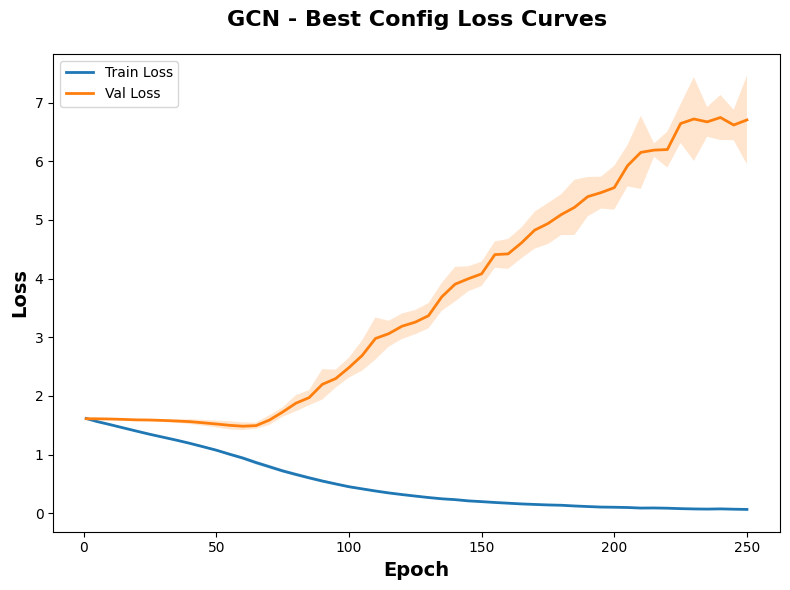

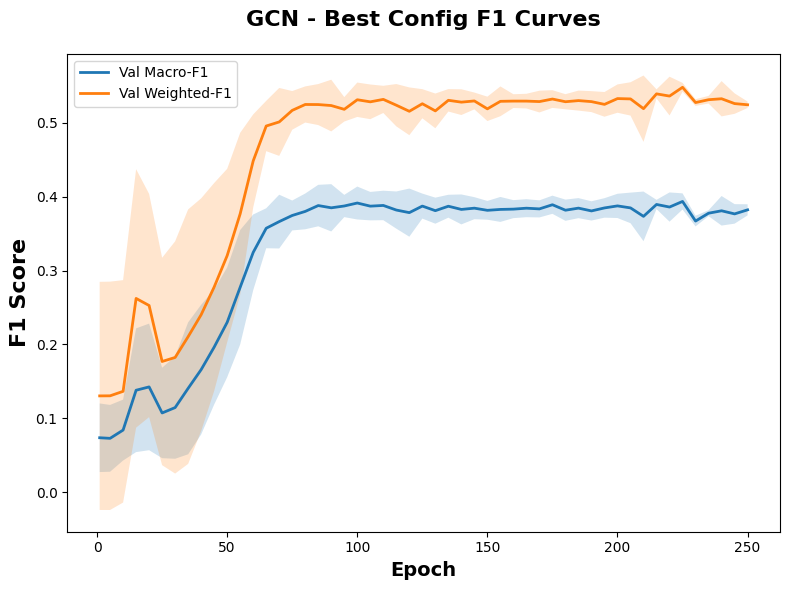

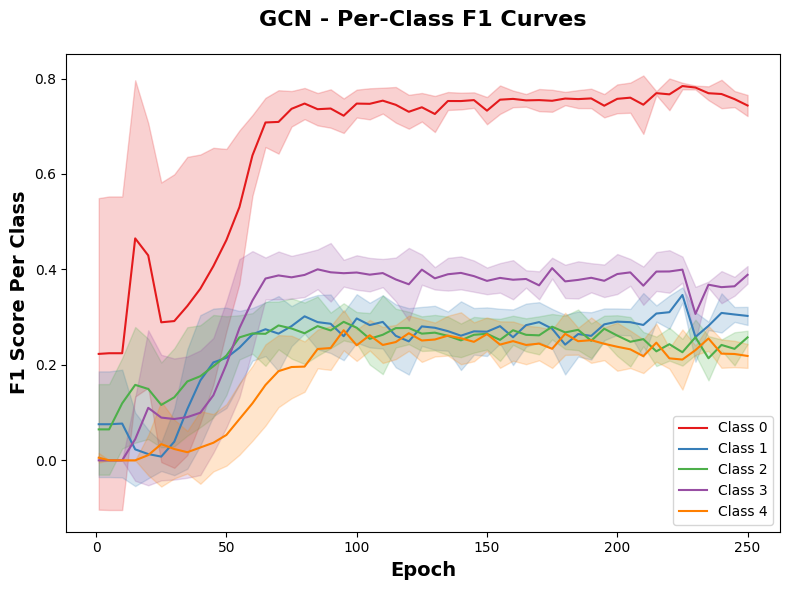

In [19]:
rerun_best_gcn("../Output/Performance/gcn_5fold_grid_results.csv",
               fold_indices, seeds,
               X_train, y_train, edge_index, edge_weight, device,
               out_dir="../Output/Figures/GCN")

[GCN-LSTM] Best config: {'lstm_hidden': 64, 'gcn_hidden': 128, 'dropout': 0.3, 'lr': 0.0005, 'weight_decay': 0.0001} loss= CE


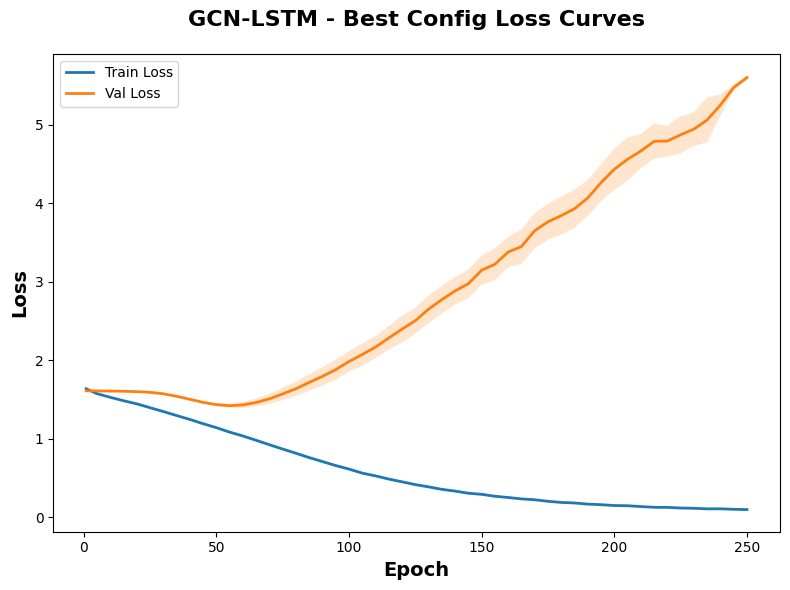

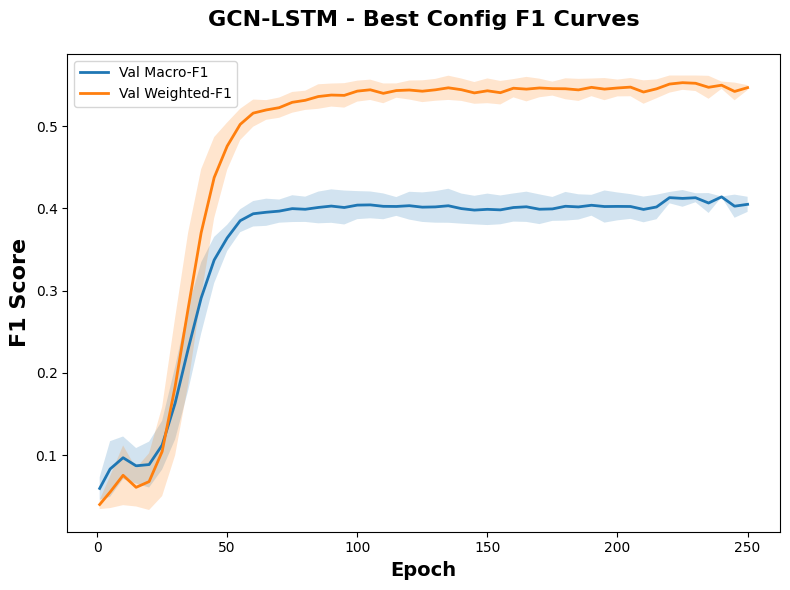

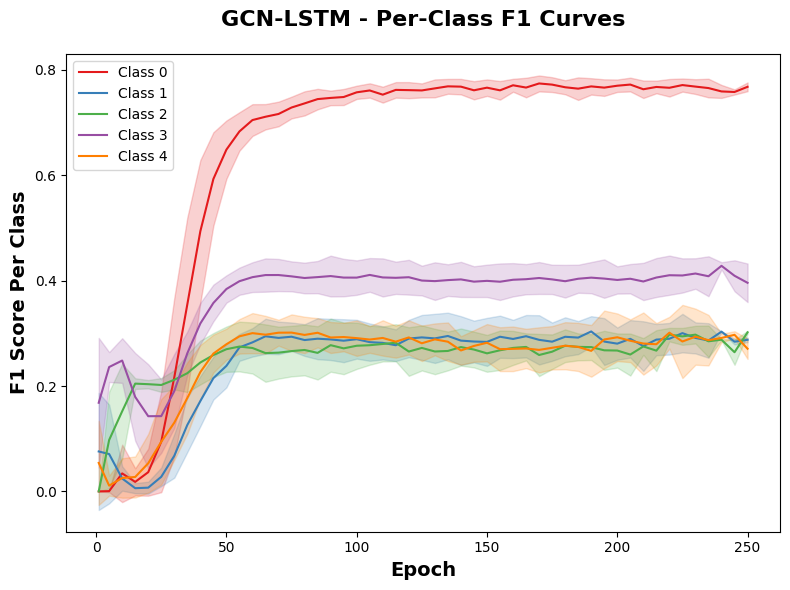

In [22]:
rerun_best_gcn_lstm("../Output/Performance/gcn_lstm_5fold_grid_results.csv",
                    fold_indices, seeds,
                    X_train_, y_train, edge_index, edge_weight, device,
                    out_dir="../Output/Figures/GCN_LSTM")